# 02 · 分類：把決策邊界畫出來

上一課跑了 KNN 分類器。這一課我們深入**分類**：比較兩個最常用的分類器，並且把模型腦中的「**決策邊界**」畫出來——看它到底把空間怎麼切。

## 學習目標

- 用 **KNN** 與 **邏輯迴歸（Logistic Regression）** 做分類並比較
- 理解什麼是 **決策邊界（decision boundary）**
- 學會把 2D 決策邊界視覺化（meshgrid + `predict`）

## 1. 只取兩個特徵，方便畫圖

鳶尾花有 4 個特徵，但人眼只看得懂 2D。為了把決策邊界畫在平面上，我們先只取**花瓣長度、花瓣寬度**這兩個（它們最有區別力）。

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data[:, 2:4]   # 只取第 2、3 欄：petal length / petal width
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("用兩個特徵:", iris.feature_names[2], "/", iris.feature_names[3])

用兩個特徵: petal length (cm) / petal width (cm)


## 2. 兩個分類器

- **KNN**：看最近的鄰居投票（上一課介紹過）
- **邏輯迴歸**：別被名字騙了，它是**分類**模型——用一條（或多條）界線把不同類別分開

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)

print(f"KNN   測試準確率：{knn.score(X_test, y_test):.1%}")
print(f"邏輯迴歸 測試準確率：{logreg.score(X_test, y_test):.1%}")

KNN   測試準確率：94.7%
邏輯迴歸 測試準確率：94.7%


## 3. 什麼是決策邊界？

模型其實是把整個特徵空間**畫分成幾塊**，每塊對應一個預測類別。塊與塊之間的分界，就是**決策邊界**。

怎麼畫？做法很機械：在平面上鋪滿密密麻麻的網格點，對**每一個點**問模型「你猜這是什麼品種」，再依答案塗色。塗完，邊界自然就浮現了。

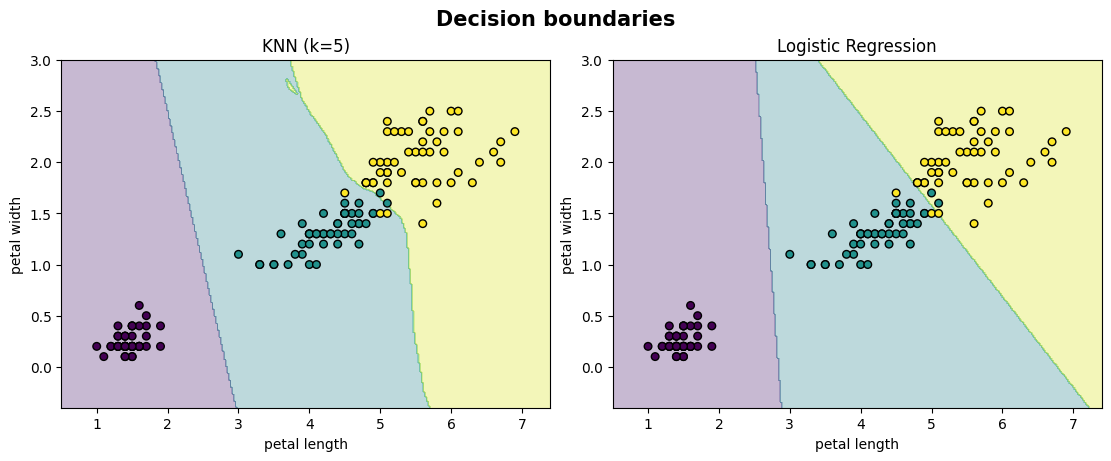

In [3]:
import matplotlib.pyplot as plt

def plot_boundary(ax, model, X, y, title):
    # 鋪一張覆蓋資料範圍的網格
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    # 對每個網格點預測，再 reshape 回網格形狀
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=30)
    ax.set_title(title)
    ax.set_xlabel("petal length")
    ax.set_ylabel("petal width")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
plot_boundary(axes[0], knn, X, y, "KNN (k=5)")
plot_boundary(axes[1], logreg, X, y, "Logistic Regression")
fig.suptitle("Decision boundaries", fontsize=15, fontweight="bold")
plt.show()

看出差別了嗎？

- **KNN** 的邊界**彎彎曲曲**，緊貼著資料——它沒有預設形狀，完全跟著鄰居走。
- **邏輯迴歸** 的邊界是**直線**——它假設類別之間用直線就能分開。

沒有誰絕對比較好：資料若本來就大致線性可分，邏輯迴歸又快又穩；若邊界很不規則，KNN 這類彈性模型更能貼合。

**動手試試**：把 KNN 的 `n_neighbors` 改成 `1`，邊界會變得更破碎（過度貼合每個點）——這正是**過擬合**的長相，第 05 課會談。

## 小結

- 分類模型把特徵空間切成數塊，分界就是**決策邊界**。
- 視覺化方法：鋪網格 → 逐點 `predict` → `contourf` 塗色。
- KNN 邊界彈性彎曲、邏輯迴歸邊界是直線——模型的**假設**決定了邊界形狀。

## 練習

1. 加入第三個分類器 `from sklearn.svm import SVC`（`SVC(kernel="rbf")`），畫進第三個子圖比較。
2. 改用另外兩個特徵（花萼 `X = iris.data[:, 0:2]`），哪一組特徵比較好分？

下一課換跑道——從「分類別」改成「預測連續數值」的**迴歸**。